In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

import seaborn as sns
import matplotlib.pyplot as plt

# read data

(214125, 9)
(214125, 9)
Unnamed: 0    214125
Age               33
Boobs             12
Height            61
Size              41
Metro          22576
DateUpdate      5316
Weight            79
Price_USD        132
dtype: int64


,Unnamed: 0,Age,Boobs,Height,Size,Metro,DateUpdate,Weight,Price_USD
0,0,27.0,3.0,173.0,46.0,"Алтуфьево, Медведково, Отрадное",2010-09-07,57.0,22.0
1,1,27.0,3.0,168.0,46.0,Кунцевская,2010-07-05,65.0,30.0
2,2,25.0,4.0,165.0,52.0,"Кутузовская, Студенческая, Киевская",2016-10-24,52.0,223.0
3,3,21.0,2.0,170.0,42.0,Тимирязевская,2006-10-25,60.0,22.0
4,4,35.0,4.0,180.0,46.0,Проспект Мира,2010-12-27,70.0,52.0


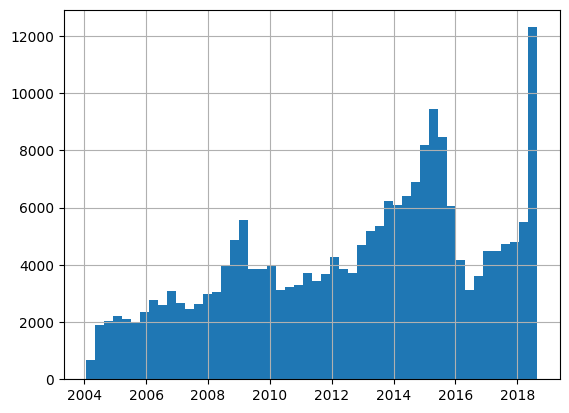

In [6]:
data = pd.read_csv('/kaggle/input/datasets/user1199/girls-from-escort-moscow-without-personal-data/out.csv')
data['DateUpdate'] = pd.to_datetime(data['DateUpdate'], format='%d.%m.%Y')
print(data.shape)
print(data.drop_duplicates().shape)
print(data.nunique())
data['DateUpdate'].hist(bins = 50)
data.head()

Графики будем смотреть на трейн выборке, чтобы не подглядывать в валидацию и тест

In [7]:
train, val_test = train_test_split(
    data,
    test_size=0.6,
    random_state=42,
    shuffle=True
)

# EDA

(array([8.385e+04, 1.514e+03, 1.400e+02, 2.800e+01, 2.800e+01, 2.300e+01,
        6.200e+01, 0.000e+00, 1.000e+00, 4.000e+00]),
 array([  15. ,  161.9,  308.8,  455.7,  602.6,  749.5,  896.4, 1043.3,
        1190.2, 1337.1, 1484. ]),
 <BarContainer object of 10 artists>)

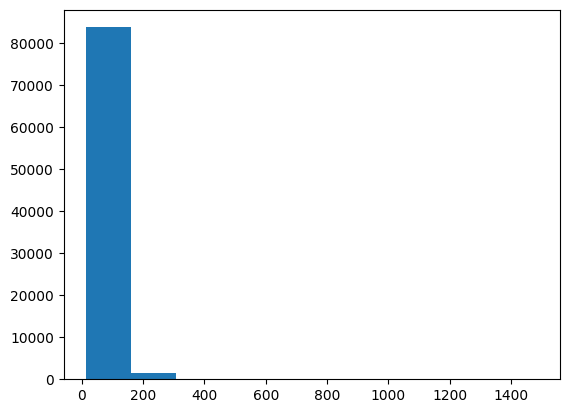

In [8]:
target = 'Price_USD'
plt.hist(train[target])

## Таргет появлялся в разное время
## По теории финансов деньги дешевеют, поэтому логично будет его продисконтировать, учитывая что у нас есть поле даты

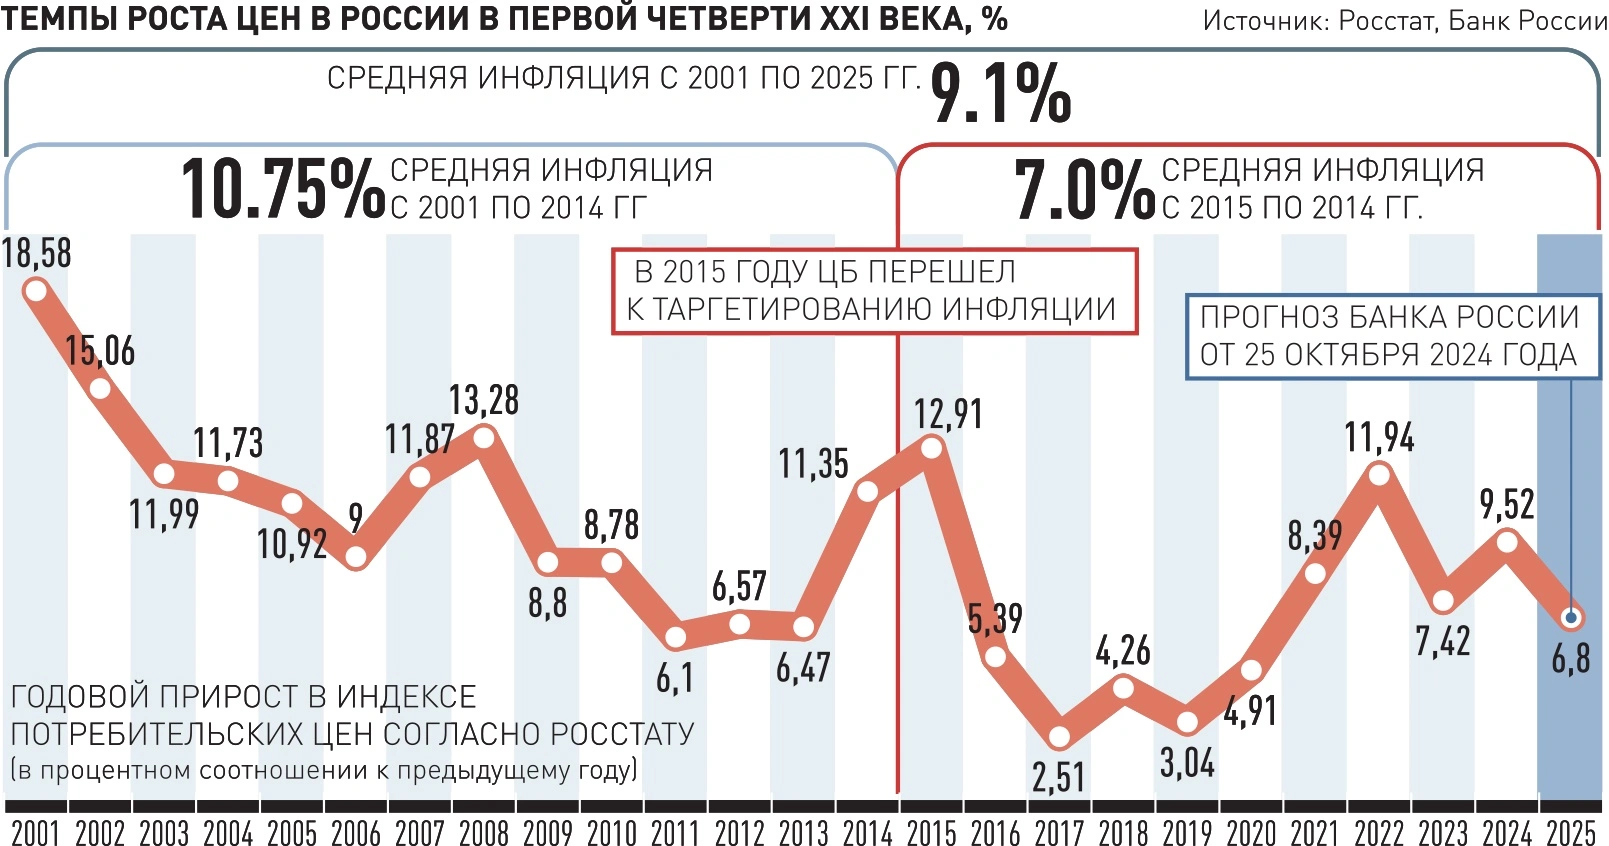

Экспертно возьмем этот коэфф равный 9.1

In [13]:
alpha = 0.091

TARGET_DATE = pd.to_datetime('2026-09-01')
delta_years = (TARGET_DATE - data['DateUpdate']).dt.days / 365.25

data[target] = data[target] * np.exp((alpha) * delta_years)

## Таргет лучше привести к нормальному распределению для регресии

(array([ 3925., 26641., 79930., 73064., 24401.,  4891.,   836.,   222.,
          121.,    94.]),
 array([3.4382925 , 3.98358295, 4.5288734 , 5.07416385, 5.6194543 ,
        6.16474476, 6.71003521, 7.25532566, 7.80061611, 8.34590656,
        8.89119701]),
 <BarContainer object of 10 artists>)

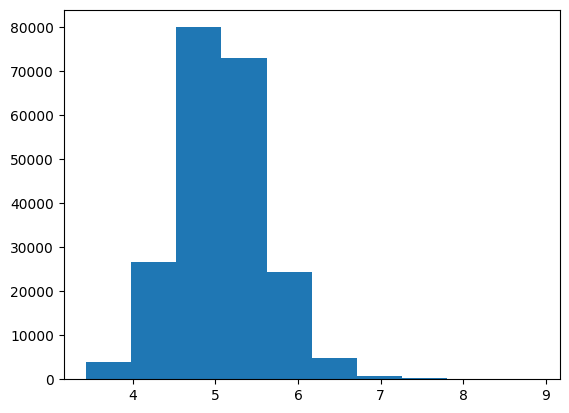

In [14]:
data[target] = np.log(data[target])
plt.hist(data[target])

## Фича метро выглядит очень странно, приведем к one-hot форме эту фичу

In [15]:
data['Metro']

0                        Алтуфьево, Медведково, Отрадное
1                                             Кунцевская
2                    Кутузовская, Студенческая, Киевская
3                                          Тимирязевская
4                                          Проспект Мира
                               ...                      
214120          Бульвар Дмитрия Донского, Южная, Ясенево
214121    Академическая, Ленинский проспект, Университет
214122                                               NaN
214123      Академическая, Калужская, Ленинский проспект
214124                 Войковская, Сокол, Водный стадион
Name: Metro, Length: 214125, dtype: object

Обработаем эти фичи

In [16]:
dummies = (
    data['Metro']
    .str.replace('\xa0', ' ', regex=False)
    .str.get_dummies(sep=',')
)

dummies.columns = dummies.columns.str.strip()

data = pd.concat([data, dummies], axis=1)

In [17]:
data.head(2)

,Unnamed: 0,Age,Boobs,Height,Size,Metro,DateUpdate,Weight,Price_USD,Авиамоторная,...,Шелепиха,Шипиловская,Шоссе энтузиастов,Щелковская,Щукинская,Электрозаводская,Электросила,Юго-Западная,Южная,Ясенево
0,0,27.0,3.0,173.0,46.0,"Алтуфьево, Медведково, Отрадное",2010-09-07,57.0,4.545548,0,...,0,0,0,0,0,0,0,0,0,0
1,1,27.0,3.0,168.0,46.0,Кунцевская,2010-07-05,65.0,4.871648,0,...,0,0,0,0,0,0,0,0,0,0



## Age

18.0 50.0


<Axes: >

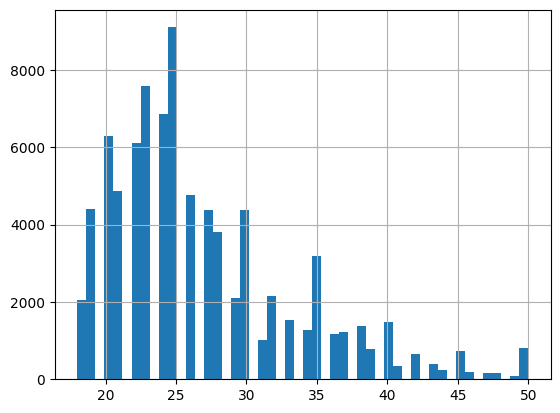

In [18]:
feature = 'Age'
print(min(train[feature]), max(train[feature]))
train[feature].hist(bins = 50)

In [19]:
data[feature] = data[feature].clip(18,50)


## Boobs

1.0 12.0


<Axes: >

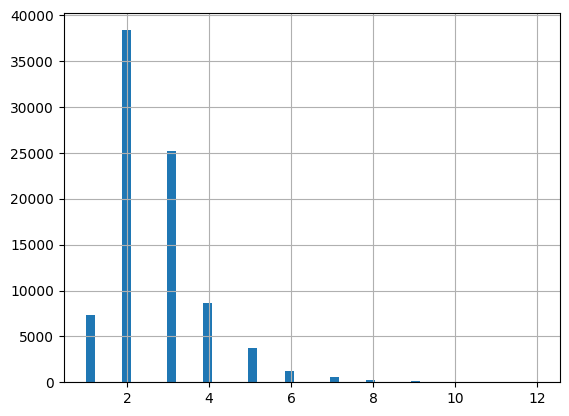

In [20]:
feature = 'Boobs'
print(min(train[feature]), max(train[feature]))
train[feature].hist(bins = 50)

In [21]:
# Все что больше это жесть - не будем переобучаться под это
data[feature] = data[feature].clip(0, 6)


## Height

140.0 200.0


<Axes: >

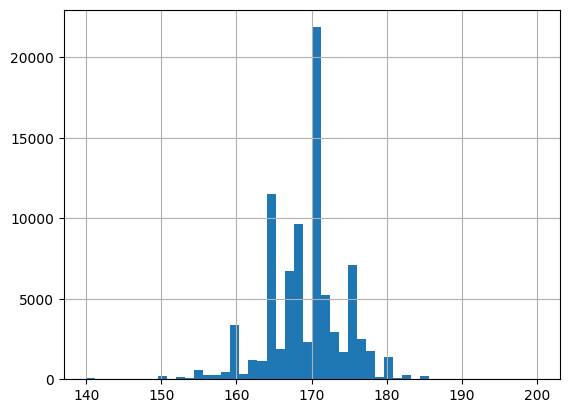

In [22]:
feature = 'Height'
print(min(train[feature]), max(train[feature]))
train[feature].hist(bins = 50)

In [23]:
# Обойдемся без мини-пекк и гигантов
data[feature] = data[feature].clip(155, 185)


## Size

35.0 80.0


<Axes: >

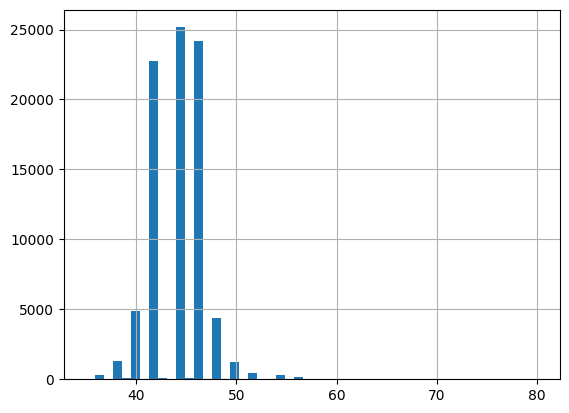

In [24]:
feature = 'Size'
print(min(train[feature]), max(train[feature]))
train[feature].hist(bins = 50)

In [25]:
# Явно выбросы в размере ног (50 итак очень много)
data[feature] = data[feature].clip(35, 50)


## Weight

35.0 80.0


<Axes: >

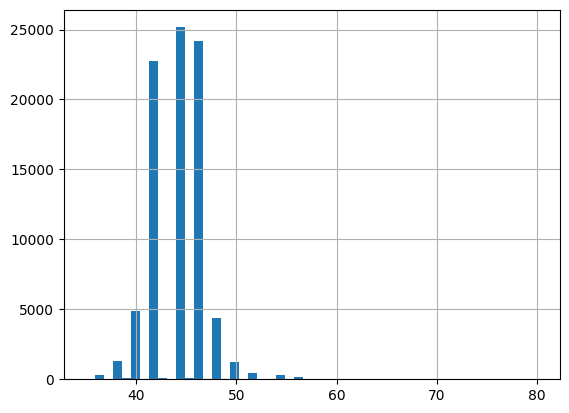

In [26]:
feature = 'Size'
print(min(train[feature]), max(train[feature]))
train[feature].hist(bins = 50)

In [27]:
# Скип бомбовозов
data[feature] = data[feature].clip(35, 60)

## Разбиваем на трейн, валидацию и тест обработанные датасет

In [28]:
train, val_test = train_test_split(
    data,
    test_size=0.6,
    random_state=42,
    shuffle=True
)
val, test = train_test_split(
    val_test,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

In [29]:
features_for_model = [
 'Age',
 'Boobs',
 'Height',
 'Size',
 'Weight',
 'Авиамоторная',
 'Автово',
 'Автозаводская',
 'Адмиралтейская',
 'Академическая',
 'Александровский сад',
 'Алексеевская',
 'Алма-Атинская',
 'Алтуфьево',
 'Андроновка',
 'Аннино',
 'Арбатская',
 'Аэропорт',
 'Бабушкинская',
 'Багратионовская',
 'Балтийская',
 'Баррикадная',
 'Бауманская',
 'Беговая',
 'Белокаменная',
 'Белорусская',
 'Беляево',
 'Бибирево',
 'Библиотека им.Ленина',
 'Битцевский парк',
 'Борисово',
 'Боровицкая',
 'Ботанический сад',
 'Братиславская',
 'Бульвар Адмирала Ушакова',
 'Бульвар Дмитрия Донского',
 'Бульвар Рокоссовского',
 'Бунинская Аллея',
 'Бутырская',
 'ВДНХ',
 'Варшавская',
 'Верхние Котлы',
 'Верхние Лихоборы',
 'Владимирская',
 'Владыкино',
 'Водный стадион',
 'Войковская',
 'Волгоградский проспект',
 'Волжская',
 'Волоколамская',
 'Воробьевы горы',
 'Выборгская',
 'Выставочная',
 'Выхино',
 'Деловой центр',
 'Деловой центр (МЦК)',
 'Динамо',
 'Дмитровская',
 'Добрынинская',
 'Домодедовская',
 'Достоевская',
 'Дубровка',
 'Елизаровская',
 'Жулебино',
 'ЗИЛ',
 'Звездная',
 'Зорге',
 'Зябликово',
 'Измайлово',
 'Измайловская',
 'Калужская',
 'Кантемировская',
 'Каховская',
 'Каширская',
 'Киевская',
 'Китай-город',
 'Кожуховская',
 'Коломенская',
 'Комендантский пр.',
 'Комсомольская',
 'Коньково',
 'Коптево',
 'Котельники',
 'Красногвардейская',
 'Краснопресненская',
 'Красносельская',
 'Красные ворота',
 'Крестьянская застава',
 'Кропоткинская',
 'Крылатское',
 'Крымская',
 'Кузнецкий мост',
 'Кузьминки',
 'Кунцевская',
 'Купчино',
 'Курская',
 'Кутузовская',
 'Ладожская',
 'Ленинский пр.',
 'Ленинский проспект',
 'Лермонтовский проспект',
 'Лесопарковая',
 'Лиговский пр.',
 'Лихоборы',
 'Локомотив',
 'Ломоносовский проспект',
 'Лубянка',
 'Лужники',
 'Люблино',
 'Марксистская',
 'Марьина Роща',
 'Марьино',
 'Маяковская',
 'Медведково',
 'Международная',
 'Менделеевская',
 'Минская',
 'Митино',
 'Молодежная',
 'Московская',
 'Мякинино',
 'Нагатинская',
 'Нагорная',
 'Нахимовский проспект',
 'Невский пр.',
 'Нижегородская',
 'Новогиреево',
 'Новокосино',
 'Новокузнецкая',
 'Новослободская',
 'Новохохловская',
 'Новочеркасская',
 'Новоясеневская',
 'Новые Черемушки',
 'Обводный канал',
 'Озерки',
 'Окружная',
 'Октябрьская',
 'Октябрьское поле',
 'Орехово',
 'Отрадное',
 'Охотный ряд',
 'Павелецкая',
 'Панфиловская',
 'Парк Победы',
 'Парк культуры',
 'Партизанская',
 'Первомайская',
 'Перово',
 'Петровский парк',
 'Петровско-Разумовская',
 'Петроградская',
 'Печатники',
 'Пионерская',
 'Пл. Ал. Невского',
 'Пл. Восстания',
 'Пл. Ленина',
 'Планерная',
 'Площадь Гагарина',
 'Площадь Ильича',
 'Площадь революции',
 'Полежаевская',
 'Политехническая',
 'Полянка',
 'Пр. Большевиков',
 'Пр. Ветеранов',
 'Пр. Просвещения',
 'Пражская',
 'Преображенская площадь',
 'Пролетарская',
 'Проспект Вернадского',
 'Проспект Мира',
 'Профсоюзная',
 'Пушкинская',
 'Пятницкое шоссе',
 'Раменки',
 'Речной вокзал',
 'Рижская',
 'Римская',
 'Ростокино',
 'Румянцево',
 'Рыбацкое',
 'Рязанский проспект',
 'Савеловская',
 'Садовая',
 'Саларьево',
 'Свиблово',
 'Севастопольская',
 'Селигерская',
 'Семеновская',
 'Сенная площадь',
 'Серпуховская',
 'Славянский бульвар',
 'Смоленская',
 'Сокол',
 'Соколиная Гора',
 'Сокольники',
 'Спартак',
 'Спасская',
 'Спортивная',
 'Сретенский бульвар',
 'Старая деревня',
 'Стрешнево',
 'Строгино',
 'Студенческая',
 'Сухаревская',
 'Сходненская',
 'Таганская',
 'Тверская',
 'Театральная',
 'Текстильщики',
 'Теплый стан',
 'Технологический институт',
 'Технопарк',
 'Тимирязевская',
 'Третьяковская',
 'Тропарёво',
 'Трубная',
 'Тульская',
 'Тургеневская',
 'Тушинская',
 'Угрешская',
 'Удельная',
 'Ул. Дыбенко',
 'Улица 1905 года',
 'Улица Ак. Янгеля',
 'Улица Горчакова',
 'Улица Скобелевская',
 'Улица Старокачаловская',
 'Университет',
 'Филевский парк',
 'Фили',
 'Фонвизинская',
 'Фрунзенская',
 'Ховрино',
 'Хорошёво',
 'Хорошёвская',
 'ЦСКА',
 'Царицыно',
 'Цветной бульвар',
 'Черкизовская',
 'Черная речка',
 'Чернышевская',
 'Чертановская',
 'Чеховская',
 'Чистые пруды',
 'Чкаловская',
 'Шаболовская',
 'Шелепиха',
 'Шипиловская',
 'Шоссе энтузиастов',
 'Щелковская',
 'Щукинская',
 'Электрозаводская',
 'Электросила',
 'Юго-Западная',
 'Южная',
 'Ясенево',
 'Авиамоторная',
 'Автово',
 'Автозаводская',
 'Адмиралтейская',
 'Академическая',
 'Александровский сад',
 'Алексеевская',
 'Алма-Атинская',
 'Алтуфьево',
 'Андроновка',
 'Аннино',
 'Арбатская',
 'Аэропорт',
 'Бабушкинская',
 'Багратионовская',
 'Балтийская',
 'Баррикадная',
 'Бауманская',
 'Беговая',
 'Белорусская',
 'Беляево',
 'Бибирево',
 'Библиотека им.Ленина',
 'Битцевский парк',
 'Борисово',
 'Боровицкая',
 'Ботанический сад',
 'Братиславская',
 'Бульвар Адмирала Ушакова',
 'Бульвар Дмитрия Донского',
 'Бульвар Рокоссовского',
 'Бунинская Аллея',
 'Бутырская',
 'ВДНХ',
 'Варшавская',
 'Василеостровская',
 'Верхние Котлы',
 'Верхние Лихоборы',
 'Владимирская',
 'Владыкино',
 'Водный стадион',
 'Войковская',
 'Волгоградский проспект',
 'Волжская',
 'Волоколамская',
 'Воробьевы горы',
 'Выборгская',
 'Выставочная',
 'Выхино',
 'Горьковская',
 'Гостиный двор',
 'Гражданский пр.',
 'Девяткино',
 'Деловой центр',
 'Деловой центр (МЦК)',
 'Динамо',
 'Дмитровская',
 'Добрынинская',
 'Домодедовская',
 'Достоевская',
 'Дубровка',
 'Жулебино',
 'ЗИЛ',
 'Зорге',
 'Зябликово',
 'Измайлово',
 'Измайловская',
 'Калужская',
 'Кантемировская',
 'Каховская',
 'Каширская',
 'Киевская',
 'Китай-город',
 'Кожуховская',
 'Коломенская',
 'Комендантский пр.',
 'Комсомольская',
 'Коньково',
 'Коптево',
 'Котельники',
 'Красногвардейская',
 'Краснопресненская',
 'Красносельская',
 'Красные ворота',
 'Крестьянская застава',
 'Кропоткинская',
 'Крылатское',
 'Крымская',
 'Кузнецкий мост',
 'Кузьминки',
 'Кунцевская',
 'Купчино',
 'Курская',
 'Кутузовская',
 'Ладожская',
 'Ленинский пр.',
 'Ленинский проспект',
 'Лермонтовский проспект',
 'Лесная',
 'Лесопарковая',
 'Лиговский пр.',
 'Лихоборы',
 'Ломоносовская',
 'Ломоносовский проспект',
 'Лубянка',
 'Лужники',
 'Люблино',
 'Марксистская',
 'Марьина Роща',
 'Марьино',
 'Маяковская',
 'Медведково',
 'Международная',
 'Менделеевская',
 'Минская',
 'Митино',
 'Молодежная',
 'Московская',
 'Московские ворота',
 'Мякинино',
 'Нагатинская',
 'Нагорная',
 'Нахимовский проспект',
 'Невский пр.',
 'Нижегородская',
 'Новогиреево',
 'Новокосино',
 'Новокрестовская',
 'Новокузнецкая',
 'Новослободская',
 'Новохохловская',
 'Новочеркасская',
 'Новоясеневская',
 'Новые Черемушки',
 'Обводный канал',
 'Озерки',
 'Окружная',
 'Октябрьская',
 'Октябрьское поле',
 'Орехово',
 'Отрадное',
 'Охотный ряд',
 'Павелецкая',
 'Панфиловская',
 'Парк Победы',
 'Парк культуры',
 'Парнас',
 'Партизанская',
 'Первомайская',
 'Перово',
 'Петровский парк',
 'Петровско-Разумовская',
 'Петроградская',
 'Печатники',
 'Пионерская',
 'Пл. Ал. Невского',
 'Пл. Восстания',
 'Пл. Ленина',
 'Пл. Мужества',
 'Планерная',
 'Площадь Гагарина',
 'Площадь Ильича',
 'Площадь революции',
 'Полежаевская',
 'Полянка',
 'Пр. Большевиков',
 'Пр. Ветеранов',
 'Пр. Просвещения',
 'Пражская',
 'Преображенская площадь',
 'Приморская',
 'Пролетарская',
 'Проспект Вернадского',
 'Проспект Мира',
 'Профсоюзная',
 'Пушкинская',
 'Пятницкое шоссе',
 'Раменки',
 'Речной вокзал',
 'Рижская',
 'Римская',
 'Ростокино',
 'Румянцево',
 'Рязанский проспект',
 'Савеловская',
 'Садовая',
 'Саларьево',
 'Свиблово',
 'Севастопольская',
 'Селигерская',
 'Семеновская',
 'Сенная площадь',
 'Серпуховская',
 'Славянский бульвар',
 'Смоленская',
 'Сокол',
 'Соколиная Гора',
 'Сокольники',
 'Спартак',
 'Спортивная',
 'Сретенский бульвар',
 'Старая деревня',
 'Строгино',
 'Студенческая',
 'Сухаревская',
 'Сходненская',
 'Таганская',
 'Тверская',
 'Театральная',
 'Текстильщики',
 'Теплый стан',
 'Технопарк',
 'Тимирязевская',
 'Третьяковская',
 'Тропарёво',
 'Трубная',
 'Тульская',
 'Тургеневская',
 'Тушинская',
 'Угрешская',
 'Улица 1905 года',
 'Улица Ак. Янгеля',
 'Улица Горчакова',
 'Улица Скобелевская',
 'Улица Старокачаловская',
 'Университет',
 'Филевский парк',
 'Фили',
 'Фонвизинская',
 'Фрунзенская',
 'Ховрино',
 'Хорошёво',
 'Хорошёвская',
 'ЦСКА',
 'Царицыно',
 'Цветной бульвар',
 'Черкизовская',
 'Черная речка',
 'Чернышевская',
 'Чертановская',
 'Чеховская',
 'Чистые пруды',
 'Чкаловская',
 'Шаболовская',
 'Шелепиха',
 'Шипиловская',
 'Шоссе энтузиастов',
 'Щелковская',
 'Щукинская',
 'Электрозаводская',
 'Электросила',
 'Юго-Западная',
 'Южная',
 'Ясенево']

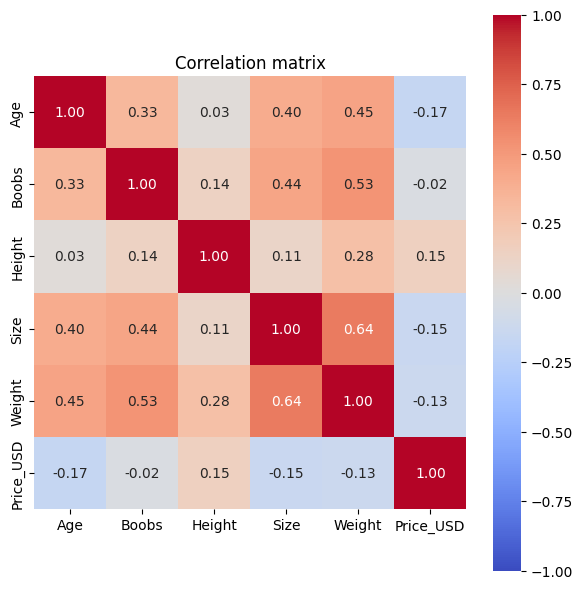

In [30]:
cols = ['Age', 'Boobs', 'Height', 'Size', 'Weight', target]

plt.figure(figsize=(6, 6))
sns.heatmap(train[cols].corr(numeric_only=True),
            annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

Матрица в линейной модели будем обратима! Так как нет слишком сильных корреляций

Для sklearn-модели должно быть 0 none

In [31]:
assert data[features_for_model + [target]].isna().sum().sum() == 0

In [32]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',  LinearRegression()),
])

model.fit(train[features_for_model], train[target])

Pipeline(steps=[('scaler', StandardScaler()), ('lr', LinearRegression())])

In [33]:
def evaluate(name, model, X, y):
    pred = model.predict(X)
    mae  = mean_absolute_error(y, pred)
    mse  = mean_squared_error(y, pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y, pred)
    print(f'{name:5s} | MAE={mae:>12.4f} | MSE={mse:>14.4f} | RMSE={rmse:>12.4f} | R2={r2:>7.4f}, MAE in USDT={np.exp(mae):>12.4f}')

evaluate('train', model, train[features_for_model], train[target])
evaluate('val',   model, val[features_for_model],   val[target])
evaluate('test',  model, test[features_for_model],  test[target])

train | MAE=      0.3595 | MSE=        0.2378 | RMSE=      0.4876 | R2= 0.1973, MAE in USDT=      1.4326
val   | MAE=      0.3610 | MSE=        0.2413 | RMSE=      0.4912 | R2= 0.1892, MAE in USDT=      1.4347
test  | MAE=      0.3597 | MSE=        0.2369 | RMSE=      0.4868 | R2= 0.1953, MAE in USDT=      1.4330


## Важность коэффциентов

In [34]:
feature_names = model.named_steps['scaler'].get_feature_names_out()
coefs = model.named_steps['lr'].coef_

coefs = pd.Series(coefs, index=feature_names).sort_values(key=abs, ascending=False)
coefs

Height          0.074148
Weight         -0.051881
Size           -0.042654
Age            -0.042516
Boobs           0.038490
                  ...   
Лесопарковая    0.000000
Купчино         0.000000
Угрешская       0.000000
Электросила     0.000000
Черная речка    0.000000
Length: 996, dtype: float64

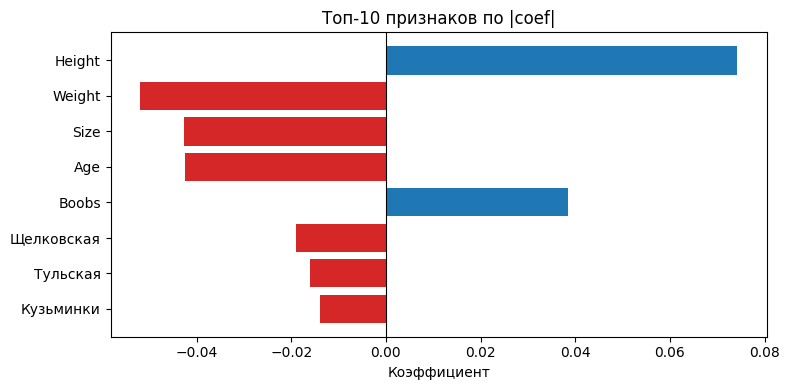

In [37]:
absolute_values = False
top_n = 10
top = coefs.head(top_n)[::-1]

plt.figure(figsize=(8, max(4, top_n * 0.3)))
colors = ['tab:red' if v < 0 else 'tab:blue' for v in top.values]
if absolute_values:
    plt.barh(top.index, abs(top.values), color=colors)
else:
    plt.barh(top.index, top.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент')
plt.title(f'Топ-{top_n} признаков по |coef|')
plt.tight_layout()
plt.show()

**Вывод:**
Сильнее всего влияет размер эскортница - ее рост вес и размер ноги - в целом зависимость такая - чем выше и строннее,с бОльшим размером и младше, тем дороже
* Чем выше эскортница, тем она дороже
* Чем больше эскортница весит тем она дешевле
* Чем больше у эксортницы размер ноги тем она дешевле

# Эластичность цены от параметров линейной модели

In [49]:
train

,Unnamed: 0,Age,Boobs,Height,Size,Metro,DateUpdate,Weight,Price_USD,Авиамоторная,...,Шелепиха,Шипиловская,Шоссе энтузиастов,Щелковская,Щукинская,Электрозаводская,Электросила,Юго-Западная,Южная,Ясенево
85047,85047,18.0,2.0,168.0,46.0,Калужская,2015-05-20,53.0,4.833636,0,...,0,0,0,0,0,0,0,0,0,0
105150,105150,21.0,2.0,185.0,46.0,Марксистская,2007-11-05,65.0,5.323786,0,...,0,0,0,0,0,0,0,0,0,0
22464,22464,34.0,6.0,175.0,48.0,"Рязанский проспект, Перово, Новогиреево",2018-06-08,60.0,4.826715,0,...,0,0,0,0,0,0,0,0,0,0
23438,23438,25.0,3.0,165.0,44.0,"Беговая, Улица 1905 года, Маяковская",2015-02-11,55.0,4.383594,0,...,0,0,0,0,0,0,0,0,0,0
75305,75305,25.0,2.0,165.0,42.0,NaN,2018-03-11,53.0,4.848889,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,119879,29.0,2.0,170.0,48.0,"Новогиреево, Перово, Шоссе энтузиастов",2011-08-13,65.0,4.770993,0,...,0,0,0,0,0,0,0,0,0,0
103694,103694,23.0,2.0,172.0,44.0,Кутузовская,2007-09-24,54.0,5.529994,0,...,0,0,0,0,0,0,0,0,0,0
131932,131932,36.0,3.0,168.0,44.0,"Пражская, Улица Ак. Янгеля, Южная",2015-10-14,58.0,4.081392,0,...,0,0,0,0,0,0,0,0,0,0
146867,146867,25.0,3.0,172.0,42.0,"Автозаводская, Павелецкая, Дубровка",2017-01-09,49.0,4.488405,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
4.833636	

In [53]:
features_for_elasticity = ['Age','Boobs','Height','Size', 'Weight']
combined = pd.concat([train[features_for_model], 
                      val[features_for_model], 
                      test[features_for_model]], 
                     axis=0, ignore_index=True)

base_pred = np.mean(model.predict(combined))

for feature in features_for_elasticity:
    combined_elasticity = combined.copy()
    combined_elasticity[feature] += 1
    elasticity_pred = np.mean(model.predict(combined_elasticity))
    print(feature, (elasticity_pred - base_pred))

Age -0.0063856462193765395
Boobs 0.03527068098278274
Height 0.015233432055594243
Size -0.01782294580122823
Weight -0.0061659924341510575


## Если бы мой сосед работал в эскорте:

In [97]:
Chebulia_age = 22
Chebulia_boobs = 0
Chebulia_height = 181
Chebulia_size = 44
Chebulia_weight = 71
intercept = 5.074158051793724

Chebulia_cost_usdt = np.exp(
                               intercept
                               + (-0.0063856462193765395) * Chebulia_age
                               + ( 0.03527068098278274)  * Chebulia_boobs
                               + ( 0.015233432055594243) * Chebulia_height
                               + (-0.01782294580122823)  * Chebulia_size
                               + (-0.0061659924341510575)* Chebulia_weight
                            )
Chebulia_cost_usdt, Chebulia_cost_usdt * 80

(np.float64(644.7934022846367), np.float64(51583.472182770936))

**Вывод**:
У соседа был бы успех в финансовом плане, если бы он занялся этим делом всерьез

# Анализ расположений:

In [38]:
import pandas as pd
import numpy as np

non_metro = {'Age', 'Boobs', 'Height', 'Size', 'Weight'}

# убираем префиксы от ColumnTransformer, если они есть
clean_index = coefs.index.str.replace(r'^(num|cat)__', '', regex=True)
coefs_clean = coefs.copy()
coefs_clean.index = clean_index

# на случай, если после one-hot одна станция превратилась в несколько колонок
coefs_clean = coefs_clean.groupby(level=0).mean()

# только метро
metro_coefs = coefs_clean[~coefs_clean.index.isin(non_metro)].copy()
metro_coefs = metro_coefs[~metro_coefs.index.str.startswith(('Age_', 'Boobs_'))]

print('станций:', len(metro_coefs))
print(metro_coefs.sort_values(key=abs, ascending=False).head(10))

станций: 265
Щелковская    -0.012129
Тульская      -0.010098
Люблино       -0.009690
Медведково    -0.009312
Кузьминки     -0.009207
Выхино        -0.009171
Новогиреево   -0.008866
Сходненская   -0.008818
Кутузовская    0.008719
Новокосино    -0.008428
dtype: float64


In [39]:
metro_coefs.mean()

np.float64(-0.0021008232423679967)

In [40]:
import os
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

CACHE = 'metro_coords.csv'

# ручные поправки для названий, которые Nominatim не находит
fix_names = {
    'Пр. Ветеранов': 'Проспект Ветеранов',
    'Пр. Просвещения': 'Проспект Просвещения',
    'Пр. Большевиков': 'Проспект Большевиков',
    'Пл. Ленина': 'Площадь Ленина',
    'Пл. Восстания': 'Площадь Восстания',
    'Пл. Ал. Невского': 'Площадь Александра Невского',
    'Пл. Мужества': 'Площадь Мужества',
    'Ленинский пр.': 'Ленинский проспект',
    'Комендантский пр.': 'Комендантский проспект',
    'Лиговский пр.': 'Лиговский проспект',
    'Невский пр.': 'Невский проспект',
    'Гражданский пр.': 'Гражданский проспект',
    'Ул. Дыбенко': 'Улица Дыбенко',
    'Улица Ак. Янгеля': 'Улица Академика Янгеля',
    'Библиотека им.Ленина': 'Библиотека имени Ленина',
}

if os.path.exists(CACHE):
    geo = pd.read_csv(CACHE)
else:
    geolocator = Nominatim(user_agent='metro_map_v1')
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1.1)

    rows = []
    for st in metro_coefs.index:
        query = fix_names.get(st, st)
        loc = geocode(f'метро {query}, Москва') or geocode(f'{query}, Москва')
        rows.append({
            'name': st,
            'lat':  loc.latitude  if loc else np.nan,
            'lon':  loc.longitude if loc else np.nan,
        })
    geo = pd.DataFrame(rows)
    geo.to_csv(CACHE, index=False)

print('не найдено:', geo['lat'].isna().sum())
print(geo[geo['lat'].isna()]['name'].tolist())

не найдено: 15
['Автово', 'Адмиралтейская', 'Василеостровская', 'Гражданский пр.', 'Деловой центр (МЦК)', 'Комендантский пр.', 'Лиговский пр.', 'Московские ворота', 'Новокрестовская', 'Новочеркасская', 'Петроградская', 'Политехническая', 'Пр. Просвещения', 'Чернышевская', 'Электросила']


In [43]:
merged = metro_coefs.rename('importance').to_frame().merge(
    geo, left_index=True, right_on='name', how='left'
)

mask = merged['lat'].between(55.4, 56.0) & merged['lon'].between(37.2, 38.0)
merged = merged[mask | merged['lat'].isna()]

In [44]:
import plotly.express as px

# 1. оставляем только те строки, где нашлись координаты
df_plot = merged.dropna(subset=['lat', 'lon']).copy()

# 2. модуль важности — для размера точки
df_plot['abs_imp'] = df_plot['importance'].abs()

# 3. (опционально) только Москва — если не нужен Питер
df_plot = df_plot[df_plot['lat'].between(55.4, 56.0)]

print('точек на карте:', len(df_plot))

# 4. рисуем
fig = px.scatter_mapbox(
    df_plot,
    lat='lat', lon='lon',
    color='importance',
    size='abs_imp',
    hover_name='name',
    hover_data={'importance': ':.4f', 'lat': False, 'lon': False, 'abs_imp': False},
    color_continuous_scale='RdBu_r',
    range_color=(-df_plot['abs_imp'].max(), df_plot['abs_imp'].max()),
    zoom=9.3, height=850,
    title='Важность станций метро',
)
fig.update_layout(
    mapbox_style='open-street-map',
    margin=dict(l=0, r=0, t=50, b=0),
)
fig.show()

точек на карте: 236


# **Вывод:** Самый большой коэфф наценки на место на северозападе и около Москвы Сити(по обе стороны реки)
# Скорее всего была коэф больше про корреляцию, нежели чем про каузуляцию, так как, в целом, более успешные эскортницы работают в дорогих местах

In [46]:
(np.exp(0.087) - np.exp(-0.0021008232423679967)) * 80

np.float64(7.439623822080206)

In [47]:
(np.exp(0.078) - np.exp(-0.0021008232423679967)) * 80

np.float64(6.65770213822463)

In [45]:
(np.exp(0.0038) + np.exp(0.003) -  2 * np.exp(-0.0021008232423679967)) * 80

np.float64(0.8807175818283675)